# 一、环境设置和数据导入

## 1.初步设置

In [162]:
#导入相关的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']  
plt.rcParams['axes.unicode_minus'] = False
#调整格式
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', None)     # 显示所有行
pd.set_option('display.width', None)        # 关闭列自动折叠换行
pd.set_option('display.max_colwidth', 30)   # 设置每列最大字符长度，避免名称截断


## 2.了解数据详细

In [163]:
#导入数据
df = pd.read_csv('data/train.csv')
# 前5行数据（完整表格）
print("===== 数据集前5行 =====")
print(df.head())
# 数据类型、缺失值统计
print("===== 数据基本信息 =====")
df.info()
# 数值字段统计（均值、最值、标准差）
print("===== 数值特征统计 =====")
print(df.describe())

===== 数据集前5行 =====
   PassengerId  Survived  Pclass                           Name     Sex   Age  \
0            1         0       3        Braund, Mr. Owen Harris    male  22.0   
1            2         1       1  Cumings, Mrs. John Bradley...  female  38.0   
2            3         1       3         Heikkinen, Miss. Laina  female  26.0   
3            4         1       1  Futrelle, Mrs. Jacques Hea...  female  35.0   
4            5         0       3       Allen, Mr. William Henry    male  35.0   

   SibSp  Parch            Ticket     Fare Cabin Embarked  
0      1      0         A/5 21171   7.2500   NaN        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   NaN        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500   NaN        S  
===== 数据基本信息 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Colum

# 二、数据清洗

## 1.查找/填充缺失值

In [164]:
print('查看缺失值')
print(df.isnull().sum())

print('-'*30)
print(df['Cabin'].value_counts())

print('-'*30)
print(df['Age'].isnull().sum())

查看缺失值
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
------------------------------
Cabin
B96 B98            4
G6                 4
C23 C25 C27        4
C22 C26            3
F33                3
F2                 3
E101               3
D                  3
C78                2
C93                2
E8                 2
D36                2
B77                2
C123               2
E121               2
E44                2
D35                2
C125               2
E67                2
B35                2
B18                2
E24                2
B49                2
C65                2
B20                2
B5                 2
B57 B59 B63 B66    2
C126               2
B51 B53 B55        2
F4                 2
C124               2
F G73              2
B58 B60            2
C52                2
D3

In [165]:
#处理embarked(登船港口)
m = df['Embarked'].mode    #找出embarked众数
df['Embarked'].fillna('m',inplace=True)

#cabin(舱号)
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

#age
median_Age = df.groupby(['Pclass','Sex'])['Age'].median()
print(median_Age)
def fill_age(row) :
    if pd.isnull(row['Age']):
        return median_Age.loc[row['Pclass'],row['Sex']]
    else:
        return row['Age']

df['Age'] = df.apply(fill_age, axis=1)


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


# 三、数据特征构造

## 1.根据姓名

In [166]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# 归并稀有头衔
df['Title'] = df['Title'].replace(
    ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Sir', 'Lady', 'Countess', 'Don', 'Jonkheer', 'Dona'], 
    'Rare'
)
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("头衔分布：")
print(df['Title'].value_counts())



头衔分布：
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


## 2.区分家庭与个人

In [167]:
# 家庭人数
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print("家庭人数分布:")
print(df['FamilySize'].value_counts().sort_index())
#个人出行
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print("独自出行分布:")
print(df['IsAlone'].value_counts())


家庭人数分布:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
独自出行分布:
IsAlone
1    537
0    354
Name: count, dtype: int64


## 3.年龄

In [168]:
df['AgeBand'] = pd.cut(
    df['Age'], 
    bins=[0, 12, 18, 35, 60, 80], 
    labels=['Child', 'Teen', 'YoungAdult', 'MiddleAged', 'Senior']
)
print("年龄段分布:")
print(df['AgeBand'].value_counts().sort_index())


年龄段分布:
AgeBand
Child          69
Teen           70
YoungAdult    514
MiddleAged    216
Senior         22
Name: count, dtype: int64


## 4.区分票价

In [169]:
df['FareBand'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'VeryHigh'])
print("票价段分布：")
print(df['FareBand'].value_counts().sort_index())

票价段分布：
FareBand
Low         223
Medium      224
High        222
VeryHigh    222
Name: count, dtype: int64


## 5.最终结果

In [170]:
print(df.head())
print("数据集形状:", df.shape)
print("新特征列表:Title, Has_Cabin, FamilySize, IsAlone, AgeBand, FareBand")

   PassengerId  Survived  Pclass                           Name     Sex   Age  \
0            1         0       3        Braund, Mr. Owen Harris    male  22.0   
1            2         1       1  Cumings, Mrs. John Bradley...  female  38.0   
2            3         1       3         Heikkinen, Miss. Laina  female  26.0   
3            4         1       1  Futrelle, Mrs. Jacques Hea...  female  35.0   
4            5         0       3       Allen, Mr. William Henry    male  35.0   

   SibSp  Parch            Ticket     Fare Cabin Embarked  Has_Cabin Title  \
0      1      0         A/5 21171   7.2500   NaN        S          0    Mr   
1      1      0          PC 17599  71.2833   C85        C          1   Mrs   
2      0      0  STON/O2. 3101282   7.9250   NaN        S          0  Miss   
3      1      0            113803  53.1000  C123        S          1   Mrs   
4      0      0            373450   8.0500   NaN        S          0    Mr   

   FamilySize  IsAlone     AgeBand  FareBand

# 四、可视化分析

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置中文字体支持（关键步骤）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


## 1.性别与存活率的关系

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\376077298.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex',
C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\376077298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex',


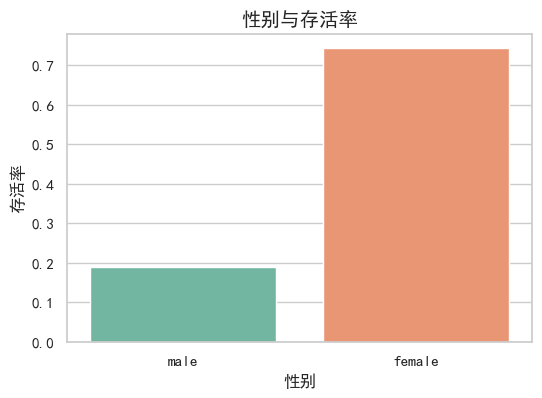

In [172]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex',
            y='Survived',
            data=df,
            ci=None,
            palette='Set2')
plt.title('性别与存活率', fontsize=14)
plt.ylabel('存活率')
plt.xlabel('性别')
plt.show()

## 2.舱位等级与存活率

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\2715566008.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived',data=df,ci=None, palette='Set3')
C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\2715566008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived',data=df,ci=None, palette='Set3')


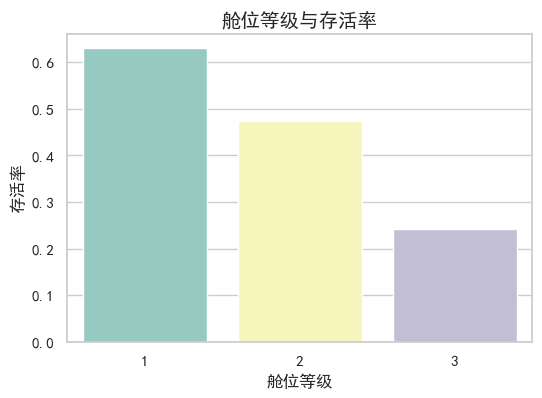

In [173]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived',data=df,ci=None, palette='Set3')
plt.title('舱位等级与存活率', fontsize=14)
plt.ylabel('存活率')
plt.xlabel('舱位等级')
plt.show()

## 3.性别+舱位对交叉分析

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\4188976068.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ci=None, palette='Set2')


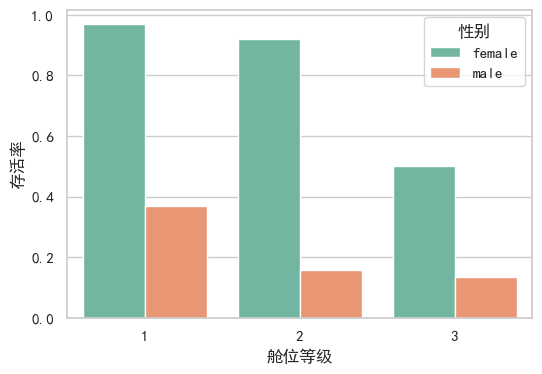

In [174]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ci=None, palette='Set2')
plt.xlabel('舱位等级')
plt.ylabel('存活率')
plt.legend(title='性别')
plt.show()

## 4.年龄分布对比

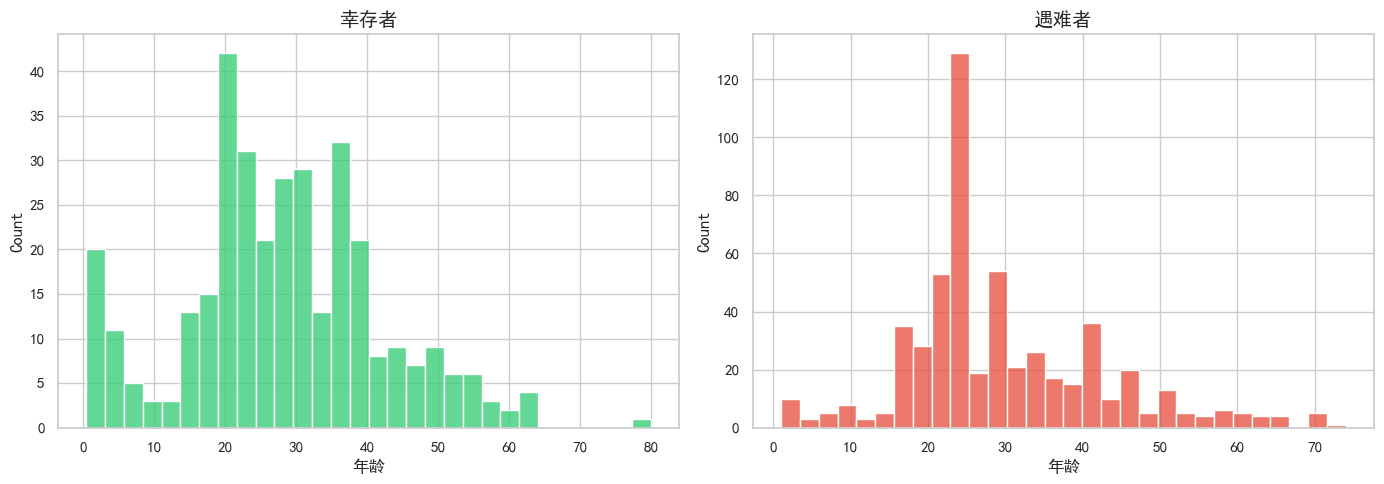

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df[df['Survived']==1]['Age'], bins=30, ax=axes[0], color='#2ecc71')
axes[0].set_title('幸存者', fontsize=14)
axes[0].set_xlabel('年龄')

sns.histplot(df[df['Survived']==0]['Age'], bins=30, ax=axes[1], color='#e74c3c')
axes[1].set_title('遇难者', fontsize=14)
axes[1].set_xlabel('年龄')
plt.tight_layout()
plt.show()

## 5.年龄段与存活率

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\1457835388.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='AgeBand', y='Survived', data=df, ci=None, palette='viridis')
C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\1457835388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeBand', y='Survived', data=df, ci=None, palette='viridis')


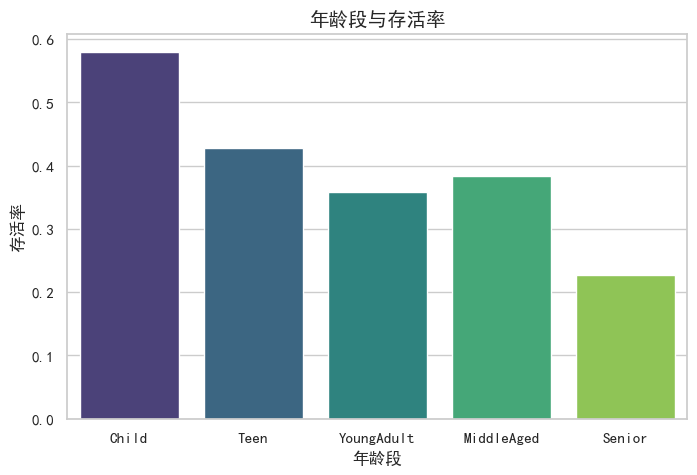

In [176]:
plt.figure(figsize=(8,5))
sns.barplot(x='AgeBand', y='Survived', data=df, ci=None, palette='viridis')
plt.title('年龄段与存活率', fontsize=14)
plt.ylabel('存活率')
plt.xlabel('年龄段')
plt.show()

## 6.家庭人数与存活率

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\2312800134.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, ci=None, palette='Blues_d')
C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\2312800134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, ci=None, palette='Blues_d')


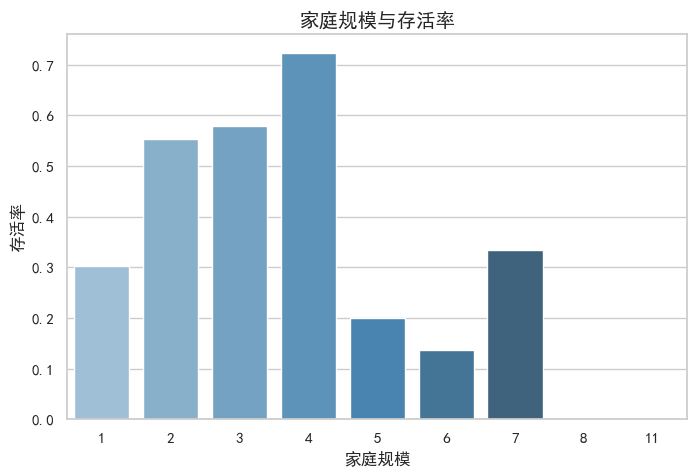

In [177]:
plt.figure(figsize=(8,5))
sns.barplot(x='FamilySize', y='Survived', data=df, ci=None, palette='Blues_d')
plt.title('家庭规模与存活率', fontsize=14)
plt.xlabel('家庭规模')
plt.ylabel('存活率')
plt.show()

## 7.票价与存活率

C:\Users\zmd\AppData\Local\Temp\ipykernel_85180\2738480017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')


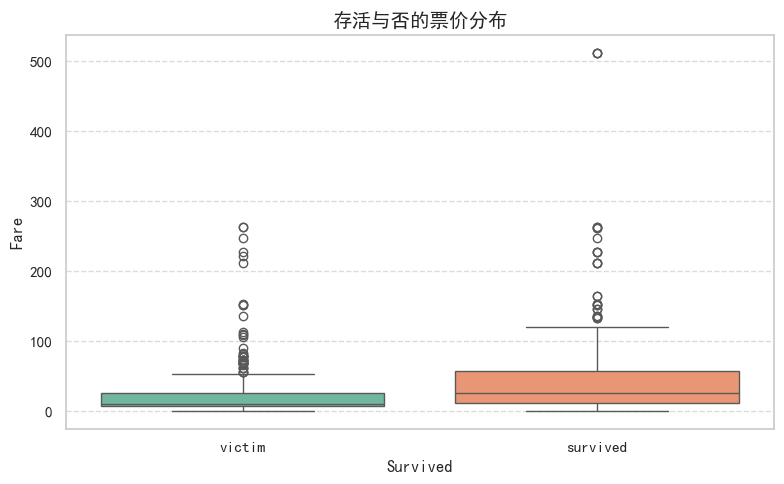

In [178]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')
plt.title('存活与否的票价分布', fontsize=14)
plt.ylabel('Fare')
plt.xticks([0,1], ['victim', 'survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 添加水平网格线，增强可读性
plt.tight_layout()  # 自动调整边距，避免标签被裁切
plt.show()

## 8.相关性热力图

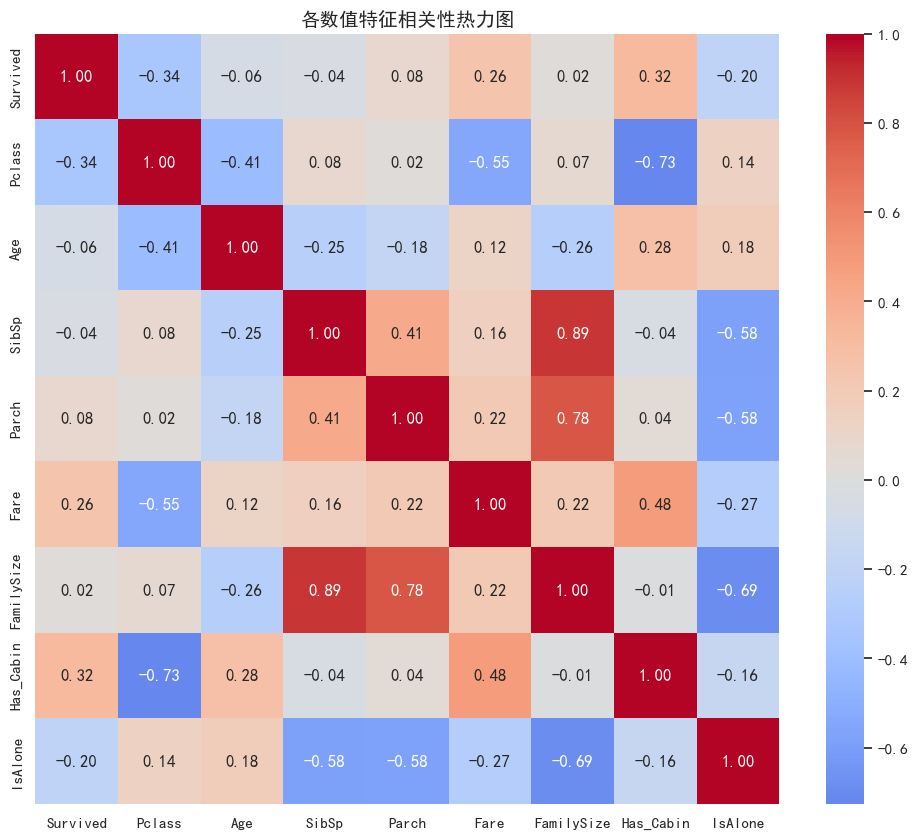

In [179]:
plt.figure(figsize=(12,10))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Has_Cabin', 'IsAlone']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('各数值特征相关性热力图', fontsize=14)
plt.show()

# 五、总结分析

通过对泰坦尼克号乘客数据的探索性分析，我们发现了以下核心规律：
1. **性别是生存的第一要素**
   - 女性存活率约74%，男性约19%。
   - 这一优势跨越所有舱位等级，即使在最危险的三等舱，女性存活率仍接近50%。

2. **社会经济地位决定逃生优先级**
   - 一等舱存活率最高（63%），三等舱最低（24%）。
   - 高票价、有独立船舱记录的乘客存活概率明显更高。

3. **年龄与生存概率紧密相关**
   - 儿童（0-12岁）有显著的存活优势。
   - 老年人（60+）存活率偏低，行动不便可能是原因。

4. **家庭结构影响逃生**
   - 适中家庭（2-4人）存活率最高，可能得益于家人互相协助。
   - 独自出行者存活率最低，缺乏照应者处于劣势。

这些洞察验证了“妇女儿童优先”的历史事实，同时也揭示了财富和社会地位在灾难中扮演的角色。后续可以基于这些特征建立分类模型，预测其他乘客的生存结果。

# 六、导出数据 

In [180]:
df.to_csv('cleaned_data.csv',index=False)
print('数据导出成功')

数据导出成功
